# Exploratory Data Analysis — Sample Labellisé

Analyse exploratoire sur l'échantillon de **420 profils** labellisés semi-manuellement (0 = humain, 1 = bot).  
Objectif : identifier les features discriminantes avant la phase de ML.

## 1. Imports & Chargement

In [23]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [24]:
df = pl.read_csv(
    "../../data/processed/labeling_sample.csv",
    separator=";",
    truncate_ragged_lines=True,
    ignore_errors=True,
)

print(f"Total rows: {len(df)}")
print(f"Columns: {df.columns}")

# drop unlabelled rows and annotation-only columns
df = df.drop_nulls("label").drop(["notes"])
print(f"\nLabelled rows: {len(df)}")

Total rows: 1000
Columns: ['user_id', 'screen_name', 'name', 'description', 'location', 'followers_count', 'friends_count', 'listed_count', 'favourites_count', 'statuses_count', 'verified', 'account_created_at', 'default_profile', 'default_profile_image', 'tweet_count_in_dataset', 'first_seen_at', 'last_seen_at', 'followers_friends_ratio', 'tweets_per_day_since_creation', 'dataset_coverage_days', 'tweets_per_day_in_dataset', 'sample_tweets', 'label', 'notes']

Labelled rows: 420


In [25]:
# Fix comma-decimal columns (French locale) and cast types
DECIMAL_COLS = [
    "followers_friends_ratio",
    "tweets_per_day_since_creation",
    "tweets_per_day_in_dataset",
]

DATE_COLS = [
    "account_created_at",
    "first_seen_at",
    "last_seen_at",
]

INT_COLS = [
    "user_id",
    "followers_count",
    "friends_count",
    "listed_count",
    "favourites_count",
    "statuses_count",
    "tweet_count_in_dataset",
    "dataset_coverage_days",
]

BOOL_COLS = [
    "verified",
    "default_profile",
]

for col in DECIMAL_COLS:
    df = df.with_columns(pl.col(col).str.replace(",", ".").cast(pl.Float64).alias(col))

for col in DATE_COLS:
    df = df.with_columns(pl.col(col).str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S").alias(col))

for col in INT_COLS:
    df = df.with_columns(pl.col(col).cast(pl.Int64))

df = df.with_columns(pl.col("label").cast(pl.Int64))

print("\nTypes after conversion:")
print(df.dtypes)


Types after conversion:
[Int64, String, String, String, String, Int64, Int64, Int64, Int64, Int64, Boolean, Datetime(time_unit='us', time_zone=None), Boolean, Boolean, Int64, Datetime(time_unit='us', time_zone=None), Datetime(time_unit='us', time_zone=None), Float64, Float64, Int64, Float64, String, Int64]


In [26]:
# Derived features
df = df.with_columns(
    # account age at last tweet (days)
    (
        (pl.col("last_seen_at") - pl.col("account_created_at"))
        .dt.total_days()
        .cast(pl.Float64)
        .alias("account_age_days")
    ),
    # profile completeness markers
    pl.col("description").is_not_null().cast(pl.Int64).alias("has_description"),
    pl.col("location").is_not_null().cast(pl.Int64).alias("has_location"),
)

print(f"Cleaned shape: {df.shape}")
df.head()

Cleaned shape: (420, 26)


user_id,screen_name,name,description,location,followers_count,friends_count,listed_count,favourites_count,statuses_count,verified,account_created_at,default_profile,default_profile_image,tweet_count_in_dataset,first_seen_at,last_seen_at,followers_friends_ratio,tweets_per_day_since_creation,dataset_coverage_days,tweets_per_day_in_dataset,sample_tweets,label,account_age_days,has_description,has_location
i64,str,str,str,str,i64,i64,i64,i64,i64,bool,datetime[μs],bool,bool,i64,datetime[μs],datetime[μs],f64,f64,i64,f64,str,i64,f64,i64,i64
965652865447587840,"""LaMfeTr3MoA5Oqu""","""الحاج محمد عبد الرحمن 2""","""مصري عروبي عاشق لمصر والامه ال…","""الإسماعيلية, مصر""",852,116,4,48293,54733,false,2018-02-19 18:22:38,true,false,37,2018-06-14 11:05:10,2018-06-17 16:21:22,0.1362,467.8,3,12.33,"""RT @nesaanews: ⛔ الفرحة الإفري…",1,117.0,1,1
1004414366777823232,"""richard30966081""","""richard""",null,"""Dominican Republic""",62,49,2,2,2207,false,2018-06-06 17:27:00,true,false,1,2018-06-14 14:30:10,2018-06-14 14:30:10,0.7903,315.29,0,0.0,"""RT @RussiaBusiness: #Sheremety…",1,7.0,0,1
995510144317493248,"""Lidiane91013817""","""Alessandra ❤""","""19 years... fan of @shawnmende…","""Brasil""",97,253,0,8937,9724,false,2018-05-13 03:44:48,true,false,1,2018-06-15 20:50:30,2018-06-15 20:50:30,2.6082,294.67,0,0.0,"""RT @ShawnMentosBR: LEMBRANDO Q…",1,33.0,1,1
927198378194296835,"""Letizialapizza1""","""ᴘᴀʀᴋ ᴍɪɴɪᴇ""",null,null,215,1032,1,64188,57055,false,2017-11-05 15:38:14,true,false,3,2018-06-15 11:35:45,2018-06-17 12:58:23,4.8,255.85,2,1.5,"""RT @BTS_ITALIA: 📹 Messaggio di…",1,223.0,0,0
3317656799,"""RoxaMP""","""Roxy""","""I’m a harry_styles fan until t…","""Davenport, FL""",2363,3095,43,138804,246341,false,2015-06-10 17:43:11,true,false,2,2018-06-14 14:50:46,2018-06-17 07:57:33,1.3098,223.54,2,1.0,"""RT @Krowd9: This is the best v…",1,1102.0,1,1


## 2. Distribution des Labels

shape: (2, 2)
┌───────┬─────┐
│ label ┆ len │
│ ---   ┆ --- │
│ i64   ┆ u32 │
╞═══════╪═════╡
│ 0     ┆ 348 │
│ 1     ┆ 72  │
└───────┴─────┘


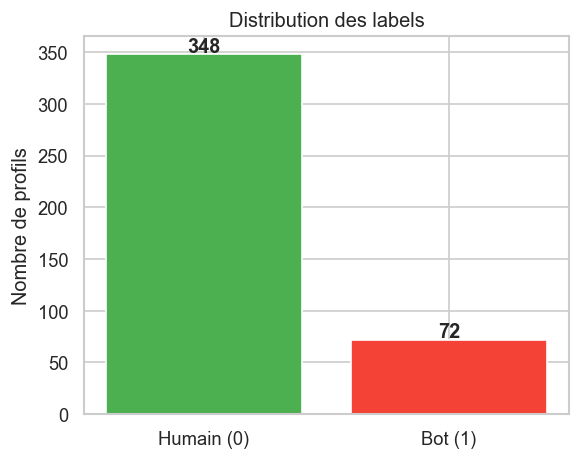

In [27]:
label_counts = df.group_by("label").len().sort("label")
print(label_counts)

fig, ax = plt.subplots(figsize=(5, 4))
colors = ["#4caf50", "#f44336"]
bars = ax.bar(
    ["Humain (0)", "Bot (1)"],
    label_counts["len"].to_list(),
    color=colors,
)
for bar, v in zip(bars, label_counts["len"].to_list()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(v),
        ha="center",
        fontweight="bold",
    )
ax.set_ylabel("Nombre de profils")
ax.set_title("Distribution des labels")
plt.tight_layout()
plt.show()

## 3. Statistiques Descriptives par Classe

In [28]:
NUM_FEATURES = [
    "followers_count",
    "friends_count",
    "listed_count",
    "favourites_count",
    "statuses_count",
    "tweet_count_in_dataset",
    "dataset_coverage_days",
    "followers_friends_ratio",
    "tweets_per_day_since_creation",
    "tweets_per_day_in_dataset",
    "account_age_days",
]

stats = (
    df.group_by("label")
    .agg(
        [pl.col(c).mean().alias(f"{c}_mean") for c in NUM_FEATURES]
        + [pl.col(c).std().alias(f"{c}_std") for c in NUM_FEATURES]
        + [pl.col(c).median().alias(f"{c}_median") for c in NUM_FEATURES]
    )
    .sort("label")
)

print(stats.transpose(include_header=True, column_names=["Humain", "Bot"]))

shape: (34, 3)
┌─────────────────────────────────┬─────────────┬─────────────┐
│ column                          ┆ Humain      ┆ Bot         │
│ ---                             ┆ ---         ┆ ---         │
│ str                             ┆ f64         ┆ f64         │
╞═════════════════════════════════╪═════════════╪═════════════╡
│ label                           ┆ 0.0         ┆ 1.0         │
│ followers_count_mean            ┆ 6092.344828 ┆ 863.930556  │
│ friends_count_mean              ┆ 1031.525862 ┆ 1001.222222 │
│ listed_count_mean               ┆ 41.545977   ┆ 1.263889    │
│ favourites_count_mean           ┆ 9485.979885 ┆ 5519.055556 │
│ …                               ┆ …           ┆ …           │
│ dataset_coverage_days_median    ┆ 0.0         ┆ 0.0         │
│ followers_friends_ratio_median  ┆ 1.0         ┆ 7.6772      │
│ tweets_per_day_since_creation_… ┆ 6.785       ┆ 1.83        │
│ tweets_per_day_in_dataset_medi… ┆ 0.0         ┆ 0.0         │
│ account_age_days_median

## 4. Distributions des Features Numériques (Boxplots Bot vs Humain)

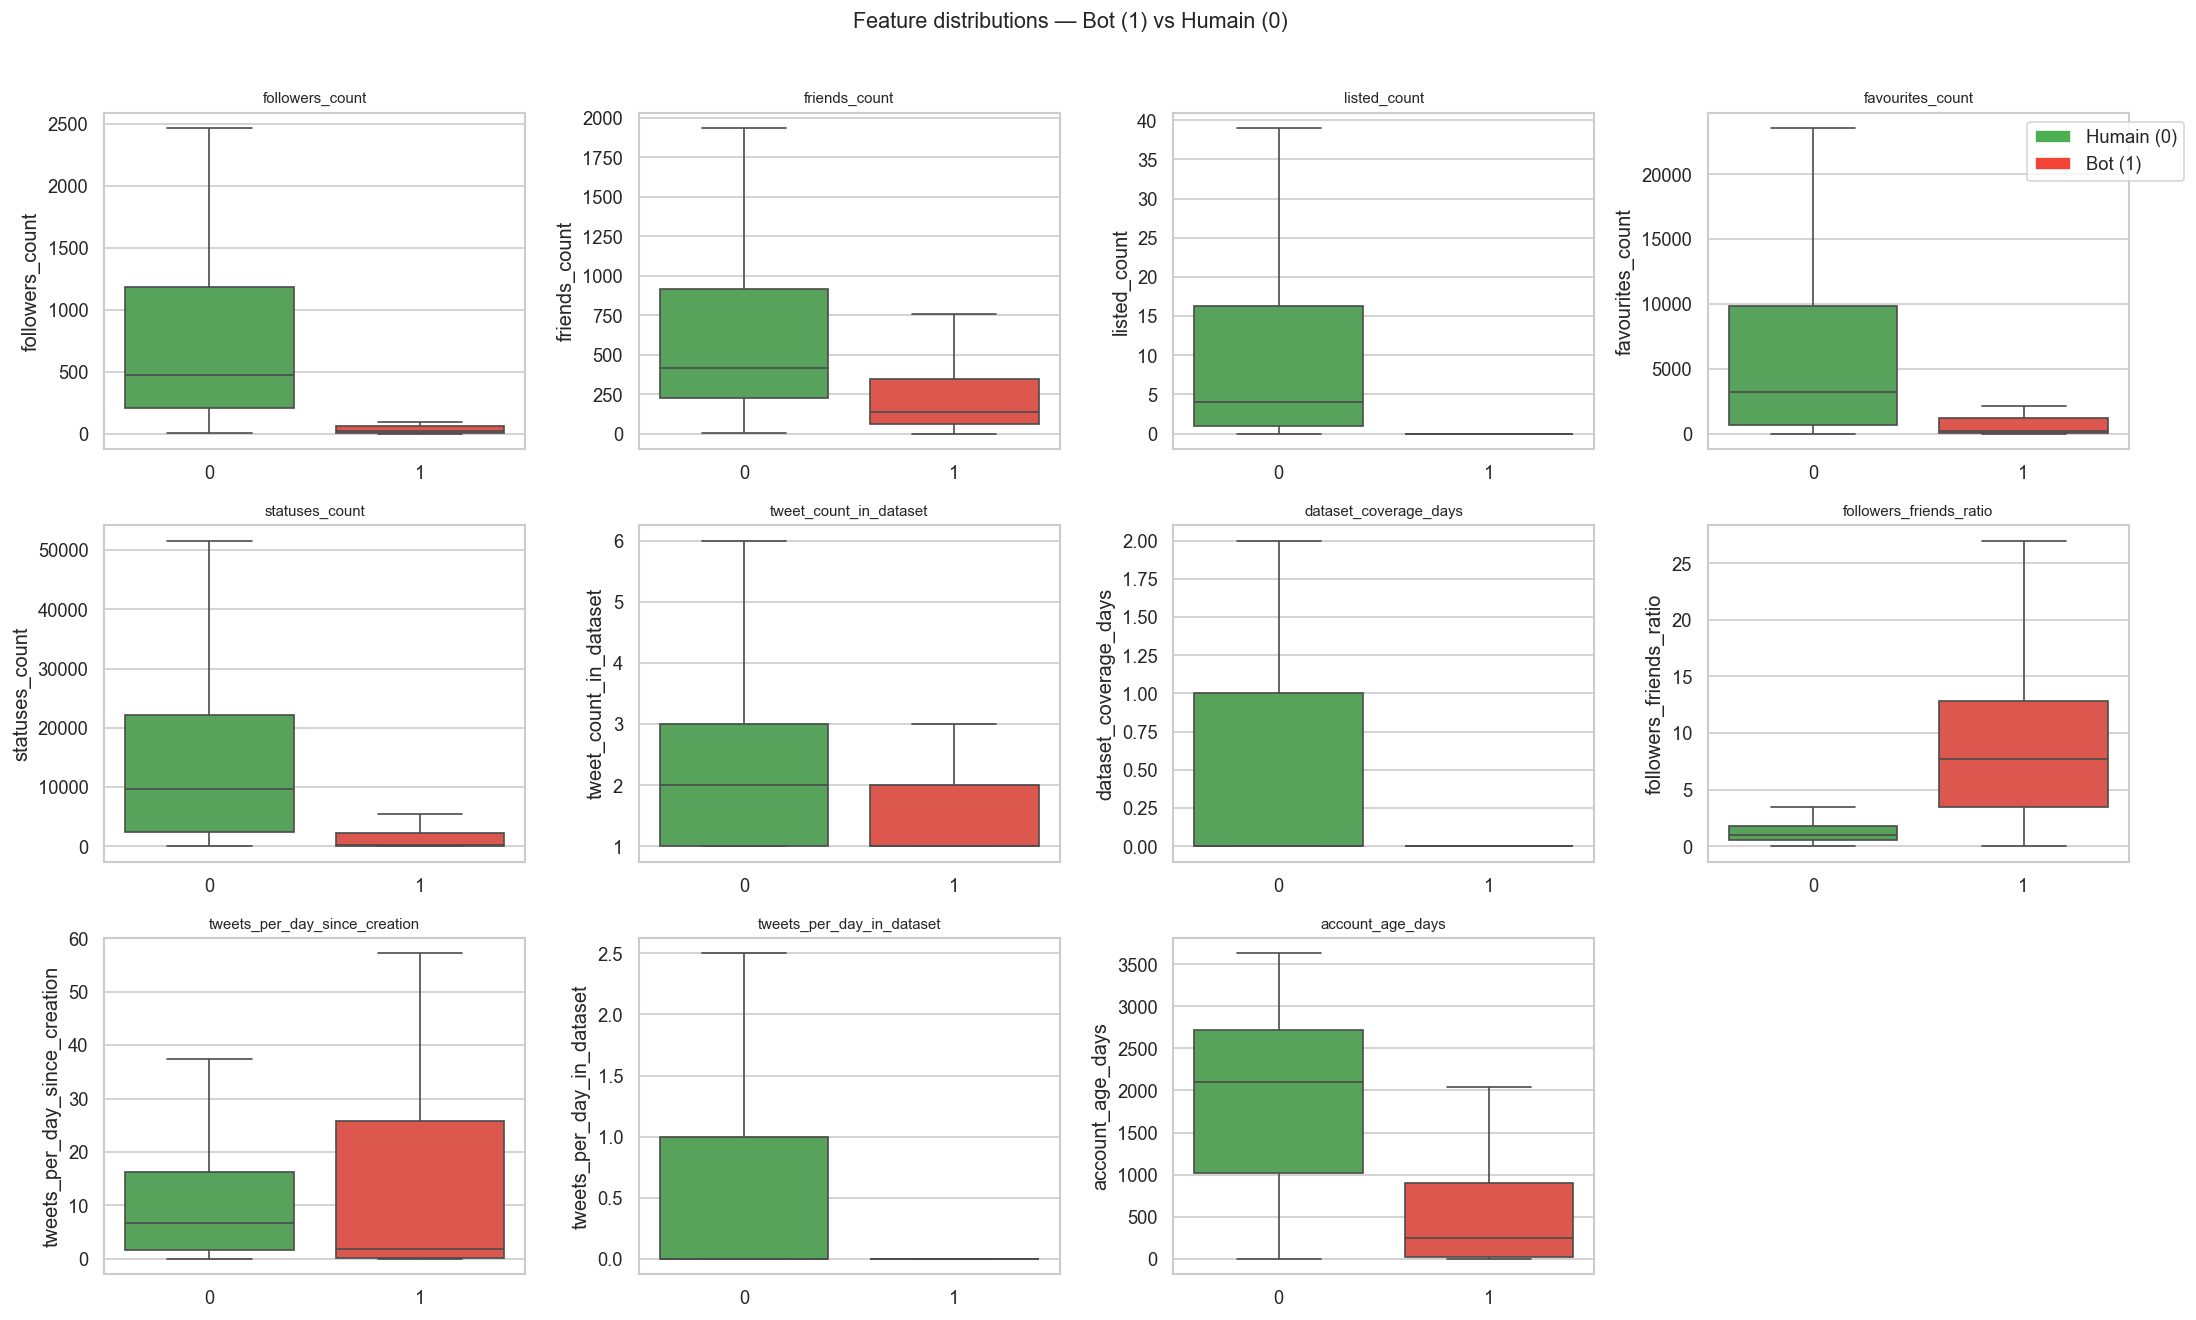

In [72]:
from matplotlib.patches import Patch

df_pd = df.select(["label"] + NUM_FEATURES)

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, feat in enumerate(NUM_FEATURES):
    ax = axes[i]
    sns.boxplot(
        data=df_pd,
        x="label",
        y=feat,
        ax=ax,
        hue="label",
        palette={0: "#4caf50", 1: "#f44336"},
        legend=False,
        showfliers=False,  # cache les outliers de l'échelle ET du visuel
        # whis=(5, 95),              # moustaches aux percentiles 5-95 → axe Y resserré
    )
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("")

# hide unused subplots
for j in range(len(NUM_FEATURES), len(axes)):
    axes[j].set_visible(False)

# add legend
legend_elements = [
    Patch(facecolor="#4caf50", label="Humain (0)"),
    Patch(facecolor="#f44336", label="Bot (1)"),
]
fig.legend(handles=legend_elements, loc="upper right", bbox_to_anchor=(1.02, 0.95), frameon=True)

plt.suptitle("Feature distributions — Bot (1) vs Humain (0)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Features Booléennes par Classe

In [30]:
BOOL_FEATS = ["verified", "default_profile", "has_description", "has_location"]

bool_stats = (
    df.group_by("label").agg([pl.col(c).mean().alias(f"{c}_pct") for c in BOOL_FEATS]).sort("label")
)

print(bool_stats.transpose(include_header=True, column_names=["Humain", "Bot"]))

shape: (5, 3)
┌─────────────────────┬──────────┬──────────┐
│ column              ┆ Humain   ┆ Bot      │
│ ---                 ┆ ---      ┆ ---      │
│ str                 ┆ f64      ┆ f64      │
╞═════════════════════╪══════════╪══════════╡
│ label               ┆ 0.0      ┆ 1.0      │
│ verified_pct        ┆ 0.025862 ┆ 0.0      │
│ default_profile_pct ┆ 0.525862 ┆ 0.888889 │
│ has_description_pct ┆ 0.908046 ┆ 0.541667 │
│ has_location_pct    ┆ 0.752874 ┆ 0.458333 │
└─────────────────────┴──────────┴──────────┘


## 6. Matrice de Corrélation

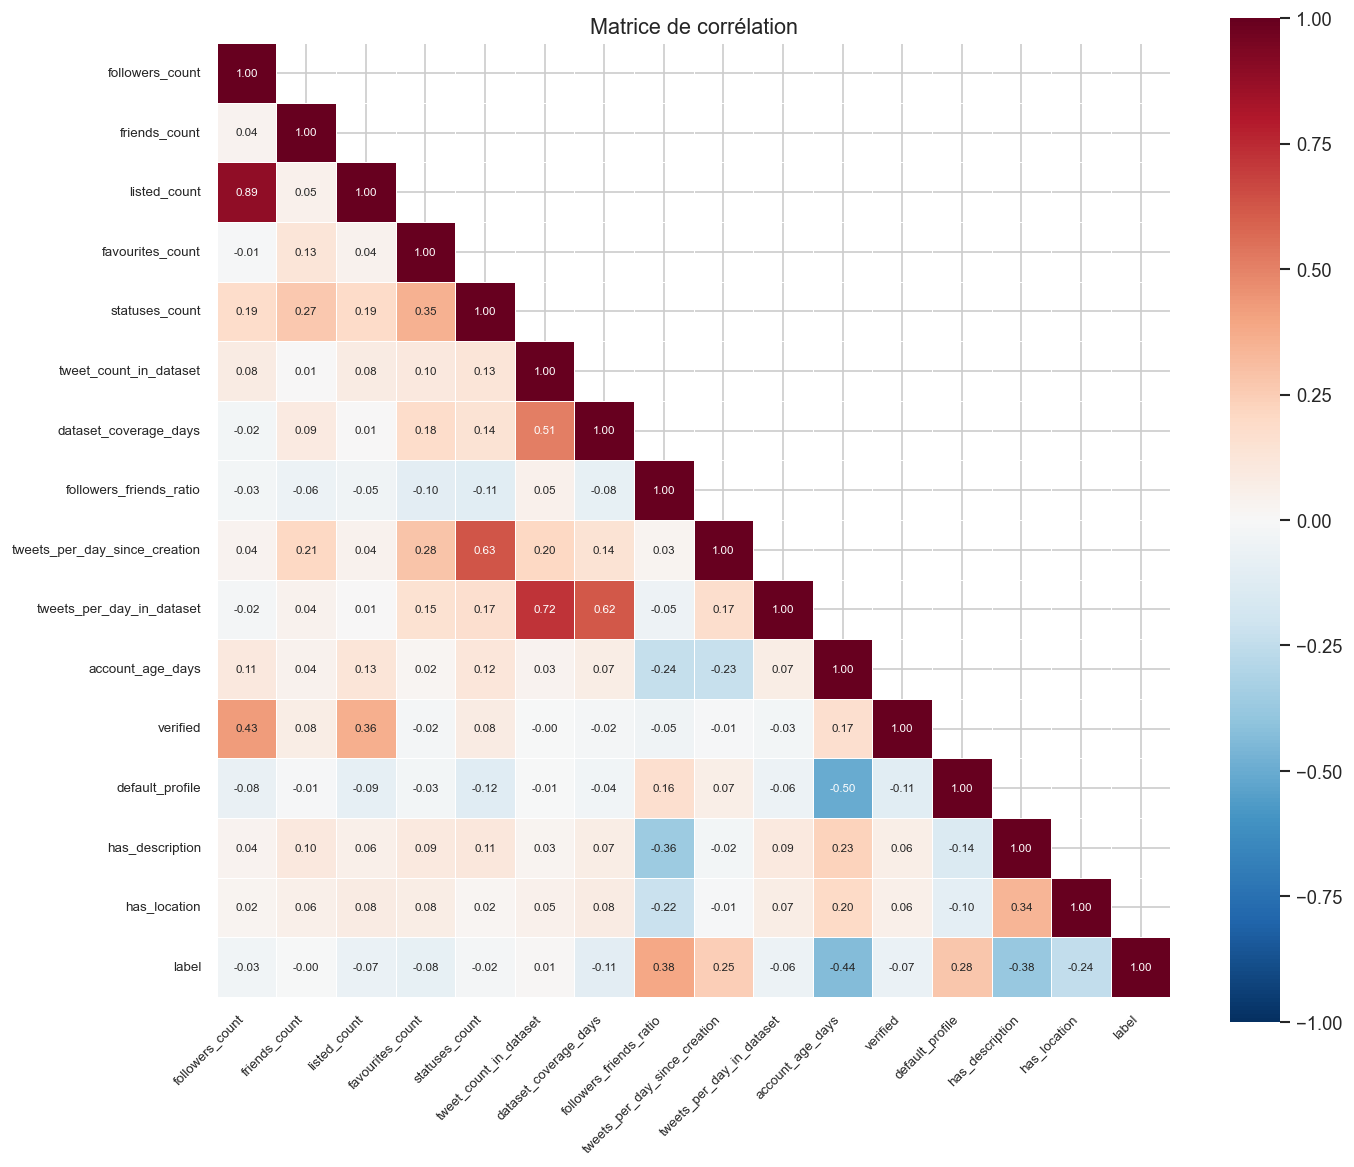

In [ ]:
CORR_FEATS = NUM_FEATURES + BOOL_FEATS + ["label"]
corr_matrix = df.select(CORR_FEATS).corr()

# keep as numpy values for seaborn but use polars column names for ticks
corr_vals = corr_matrix.to_numpy()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones(corr_vals.shape, dtype=bool), k=1)
sns.heatmap(
    corr_vals,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 7},
    xticklabels=corr_matrix.columns,
    yticklabels=corr_matrix.columns,
)
ax.set_title("Matrice de corrélation", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

In [41]:
corr_matrix.show(16)

followers_count,friends_count,listed_count,favourites_count,statuses_count,tweet_count_in_dataset,dataset_coverage_days,followers_friends_ratio,tweets_per_day_since_creation,tweets_per_day_in_dataset,account_age_days,verified,default_profile,has_description,has_location,label
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.035589,0.885072,-0.010744,0.186348,0.083442,-0.023752,-0.029572,0.037728,-0.023065,0.105735,0.428676,-0.075685,0.03672,0.023592,-0.034143
0.035589,1.0,0.047542,0.128291,0.273159,0.006214,0.090001,-0.059102,0.205758,0.039675,0.040614,0.077462,-0.014704,0.101767,0.062322,-0.004192
0.885072,0.047542,1.0,0.039754,0.194051,0.080682,0.005009,-0.045283,0.039106,0.005836,0.12504,0.364993,-0.088569,0.059451,0.082151,-0.069398
-0.010744,0.128291,0.039754,1.0,0.352669,0.103212,0.184384,-0.103254,0.281354,0.153473,0.019224,-0.021867,-0.027033,0.094666,0.077174,-0.079012
0.186348,0.273159,0.194051,0.352669,1.0,0.12597,0.14384,-0.110544,0.629412,0.169648,0.119393,0.084787,-0.121156,0.109589,0.020824,-0.022066
0.083442,0.006214,0.080682,0.103212,0.12597,1.0,0.512983,0.052326,0.204552,0.719489,0.033239,-0.003243,-0.005276,0.026329,0.050063,0.011677
-0.023752,0.090001,0.005009,0.184384,0.14384,0.512983,1.0,-0.080538,0.141841,0.619096,0.071451,-0.017888,-0.037821,0.072454,0.082788,-0.1072
-0.029572,-0.059102,-0.045283,-0.103254,-0.110544,0.052326,-0.080538,1.0,0.025762,-0.048975,-0.235307,-0.045755,0.164182,-0.363476,-0.222944,0.383801
0.037728,0.205758,0.039106,0.281354,0.629412,0.204552,0.141841,0.025762,1.0,0.174484,-0.22738,-0.012455,0.066072,-0.024873,-0.010356,0.247081


## 7. Focus par métriques 

### Ratio friends/followers (scatter plot)

In [60]:
viz = df.with_columns(
    pl.when(pl.col("label") == 0).then(pl.lit("Humain")).otherwise(pl.lit("Bot")).alias("Classe"),
    pl.col("followers_count").log1p().alias("log_followers"),
    pl.col("friends_count").log1p().alias("log_friends"),
    pl.col("statuses_count").log1p().alias("log_statuses"),
    pl.col("favourites_count").log1p().alias("log_likes"),
)
colors = {"Humain": "#4caf50", "Bot": "#f44336"}

In [61]:
df_humains = viz.filter(pl.col("label") == 0)
df_bots = viz.filter(pl.col("label") == 1)

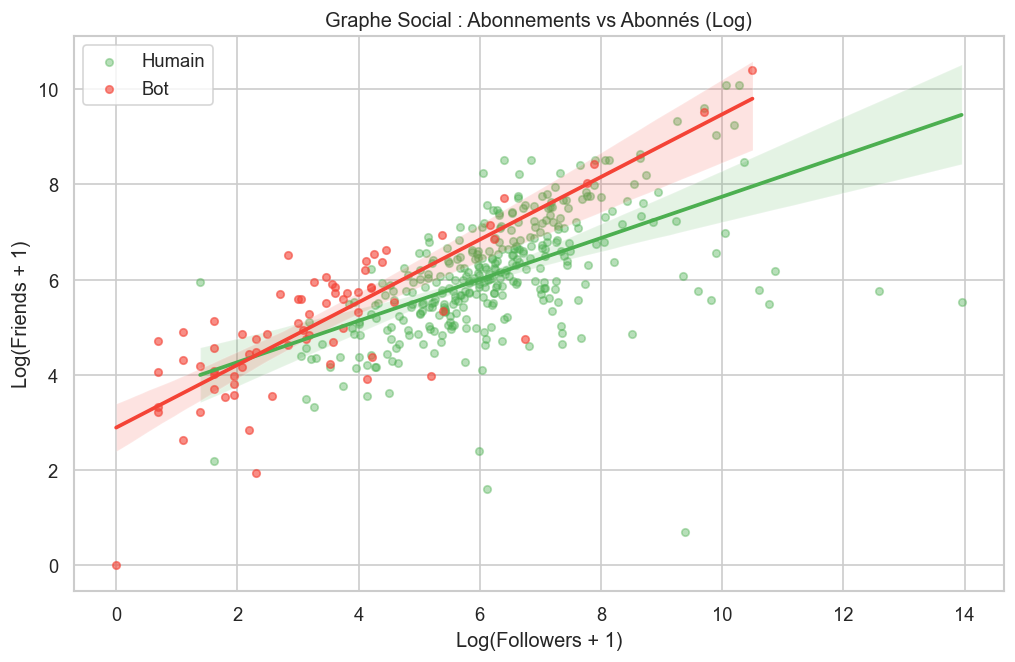

In [62]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x=df_humains["log_followers"].to_numpy(),
    y=df_humains["log_friends"].to_numpy(),
    label="Humain",
    scatter_kws={"alpha": 0.4, "s": 20},
    color=colors["Humain"],
)

sns.regplot(
    x=df_bots["log_followers"].to_numpy(),
    y=df_bots["log_friends"].to_numpy(),
    label="Bot",
    scatter_kws={"alpha": 0.6, "s": 20},
    color=colors["Bot"],
)

plt.title("Graphe Social : Abonnements vs Abonnés (Log)")
plt.xlabel("Log(Followers + 1)")
plt.ylabel("Log(Friends + 1)")
plt.legend()
plt.show()

### Statuses / Likes (scatter plot)

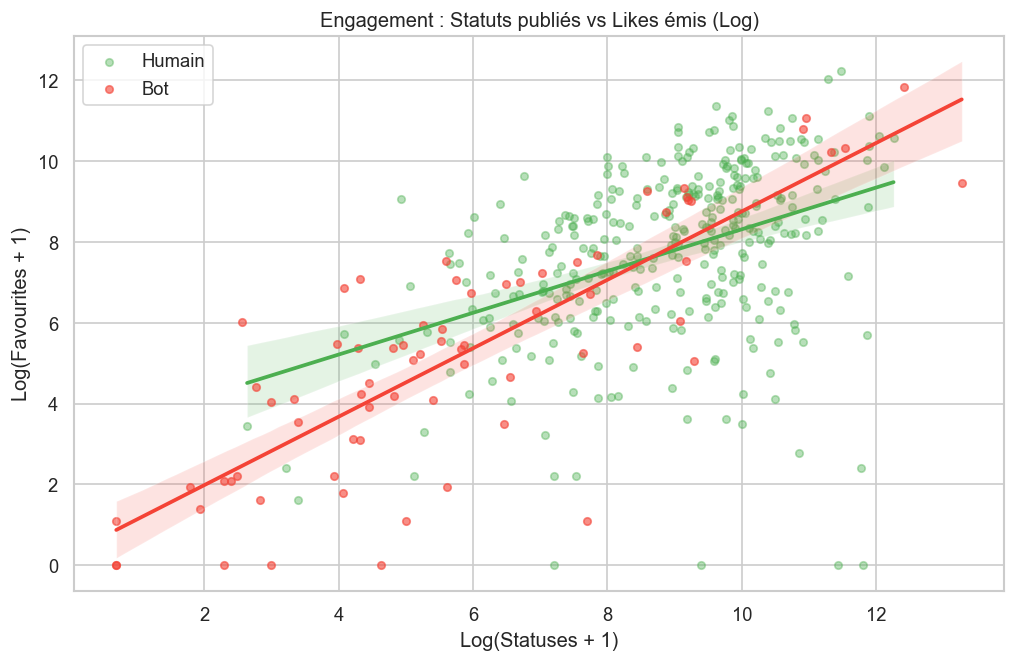

In [63]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x=df_humains["log_statuses"].to_numpy(),
    y=df_humains["log_likes"].to_numpy(),
    label="Humain",
    scatter_kws={"alpha": 0.4, "s": 20},
    color=colors["Humain"],
)

sns.regplot(
    x=df_bots["log_statuses"].to_numpy(),
    y=df_bots["log_likes"].to_numpy(),
    label="Bot",
    scatter_kws={"alpha": 0.6, "s": 20},
    color=colors["Bot"],
)

plt.title("Engagement : Statuts publiés vs Likes émis (Log)")
plt.xlabel("Log(Statuses + 1)")
plt.ylabel("Log(Favourites + 1)")
plt.legend()
plt.show()

/var/folders/v7/vfpcnz_17cl613m8n8f3_6z40000gn/T/ipykernel_56433/1660756983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


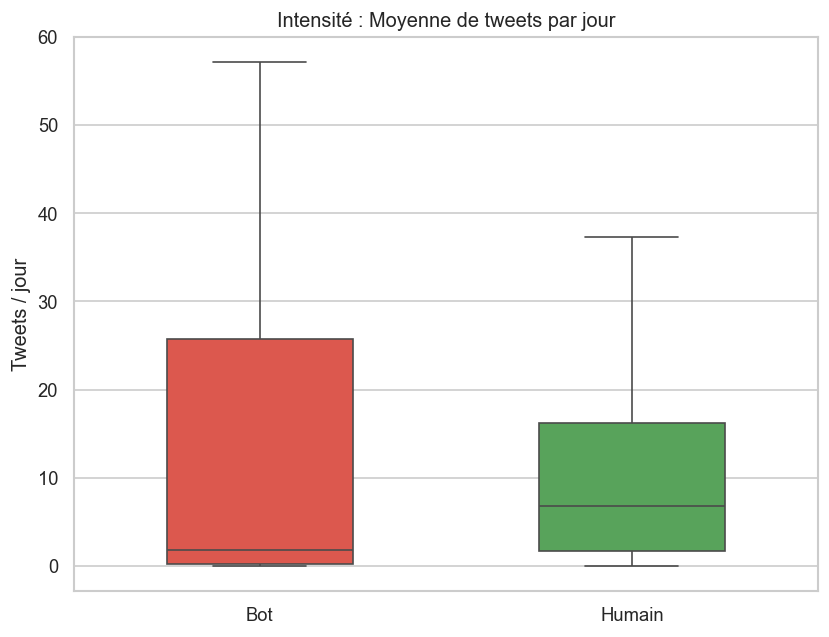

In [64]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=viz,
    x="Classe",
    y="tweets_per_day_since_creation",
    palette=colors,
    showfliers=False,  # On cache les outliers extrêmes pour une meilleure lisibilité
    width=0.5,
)

plt.title("Intensité : Moyenne de tweets par jour")
plt.ylabel("Tweets / jour")
plt.xlabel("")
plt.show()

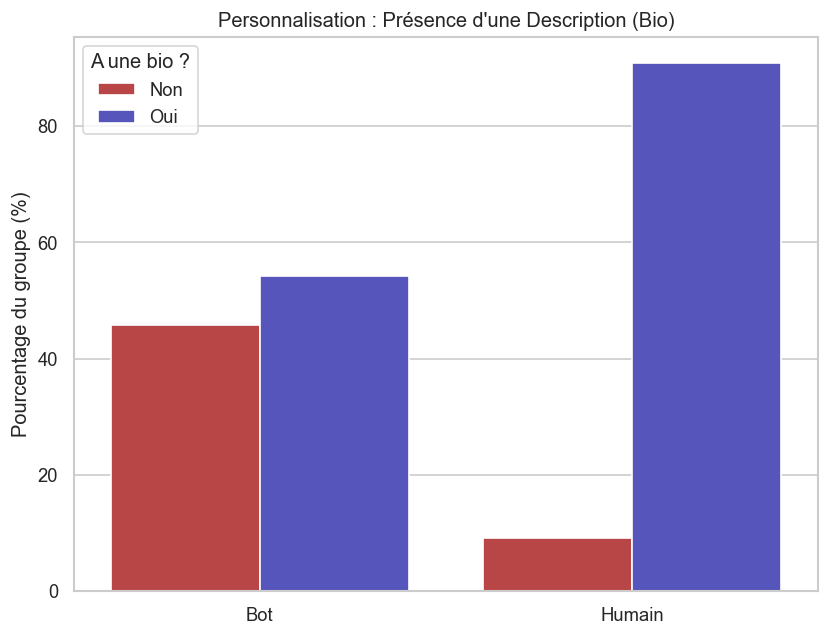

In [71]:
# Calcul des stats en Polars pur
stats_bio = (
    viz.group_by(["Classe", "has_description"])
    .len()
    .with_columns((pl.col("len") / pl.col("len").sum().over("Classe") * 100).alias("pourcentage"))
    .sort(["Classe", "has_description"])
)

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=stats_bio,
    x="Classe",
    y="pourcentage",
    hue="has_description",
    palette=["#CC3333", "#4444CC"],
)
plt.title("Personnalisation : Présence d'une Description (Bio)")
plt.ylabel("Pourcentage du groupe (%)")
plt.xlabel("")

handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Non", "Oui"], title="A une bio ?")
plt.show()

## 8. SPOT Scoring (adapté de Perez et al.)

Trois dimensions :
- **Agressivité (Ap)** : `(tweets_per_day + friends_per_day) / fmax_daily` (adapté en journalier)  
- **Visibilité (Vp)** : `(avg_mentions*C@ + avg_hashtags*C#) / 140`  
- **Danger (Dp)** : proxy = ratio de tweets contenant une URL

In [35]:
FMAX_DAILY = 350  # Twitter API rate limit adapted to daily
C_MENTION = 11.4  # avg char cost of @mention
C_HASHTAG = 11.6  # avg char cost of #hashtag

df = df.with_columns(
    # Extract proxy features from the 5 sample tweets we have (simple string match)
    (pl.col("sample_tweets").str.count_matches(r"@") / 5).alias("avg_mentions_per_tweet"),
    (pl.col("sample_tweets").str.count_matches(r"#") / 5).alias("avg_hashtags_per_tweet"),
    (pl.col("sample_tweets").str.count_matches(r"http") / 5).alias("avg_urls_per_tweet"),
    # friends per day (proxy: total / age)
    (
        pl.col("friends_count").cast(pl.Float64) / pl.max_horizontal(pl.col("account_age_days"), 1)
    ).alias("friends_per_day"),
)

# SPOT dimensions
df = df.with_columns(
    # Aggressiveness (adapted to daily actions)
    ((pl.col("tweets_per_day_since_creation") + pl.col("friends_per_day")) / FMAX_DAILY).alias(
        "SPOT_aggressiveness"
    ),
    # Visibility
    (
        (
            pl.col("avg_mentions_per_tweet") * C_MENTION
            + pl.col("avg_hashtags_per_tweet") * C_HASHTAG
        )
        / 140
    ).alias("SPOT_visibility"),
    # Danger proxy: URL per tweet ratio (normalised 0-1 estimate)
    pl.col("avg_urls_per_tweet").alias("SPOT_danger"),
)

print("SPOT scores per label:")
df.group_by("label").agg(
    [
        pl.col("SPOT_aggressiveness").mean(),
        pl.col("SPOT_visibility").mean(),
        pl.col("SPOT_danger").mean(),
    ]
).sort("label")

SPOT scores per label:


label,SPOT_aggressiveness,SPOT_visibility,SPOT_danger
i64,f64,f64,f64
0,0.0413,0.077379,0.228736
1,0.148025,0.09406,0.161111


/var/folders/v7/vfpcnz_17cl613m8n8f3_6z40000gn/T/ipykernel_56433/3961701574.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spot_pd, x="label", y=feat, ax=axes[i],
/var/folders/v7/vfpcnz_17cl613m8n8f3_6z40000gn/T/ipykernel_56433/3961701574.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spot_pd, x="label", y=feat, ax=axes[i],
/var/folders/v7/vfpcnz_17cl613m8n8f3_6z40000gn/T/ipykernel_56433/3961701574.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=spot_pd, x="label", y=feat, ax=axes[i],


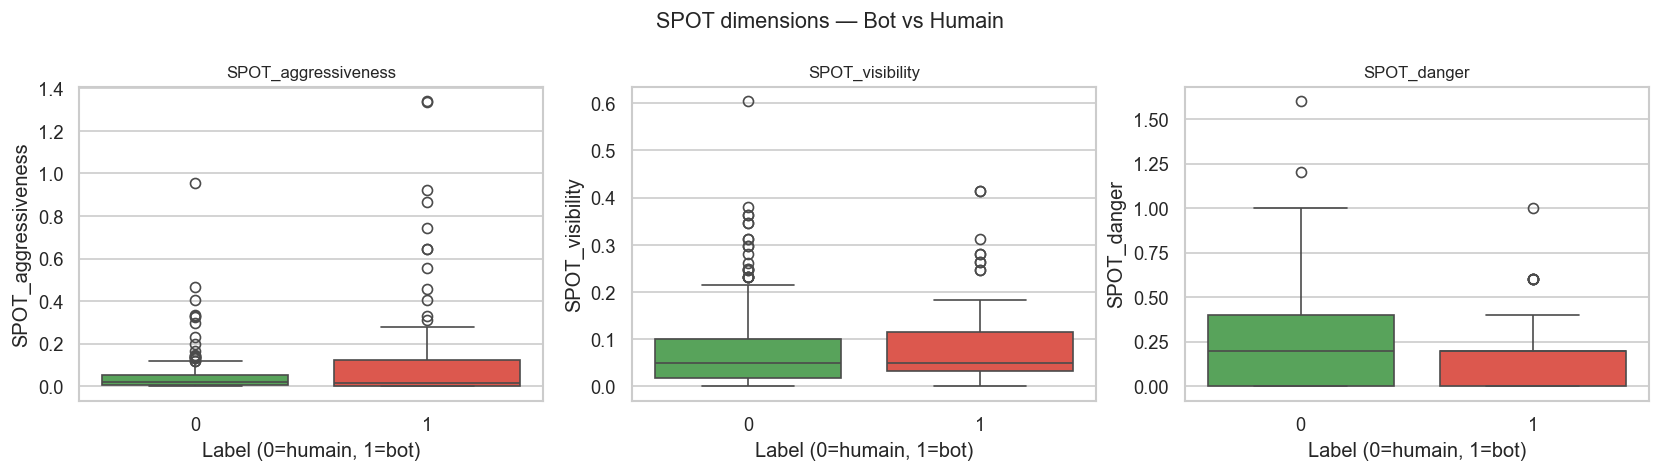

In [37]:
# Boxplots of SPOT dimensions
spot_features = ["SPOT_aggressiveness", "SPOT_visibility", "SPOT_danger"]
spot_pd = df.select(["label"] + spot_features).to_pandas()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, feat in enumerate(spot_features):
    sns.boxplot(
        data=spot_pd, x="label", y=feat, ax=axes[i], palette={"0": "#4caf50", "1": "#f44336"}
    )
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("Label (0=humain, 1=bot)")
plt.suptitle("SPOT dimensions — Bot vs Humain", fontsize=13)
plt.tight_layout()
plt.show()